# **Section 7: XGBoost Classification**

In this notebook, I will train and evaluate XGBoost (Gradient Boosting) models. XGBoost is particularly well-suited for high-dimensional genomic data with limited samples. I will start with a baseline model and then tune hyperparameters using cross-validated grid search.


## **1. Importing the Data**

Let's import the data and split it into training, validation and test sets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
sns.set_palette("pastel")

### **1.1 Load SNP Features**

In [2]:
# Load SNP features and labels
snp_data = pd.read_csv('snps_cleaned_SXT.csv', index_col=0)
profiles = pd.read_csv('SXT.csv', index_col=0)

X = snp_data.values
y = profiles.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

Data shape: (227, 9754)
Label shape: (227, 1)
Categories: [0 1]


### **1.2 Split Data into Train, Validation, and Test Sets**

In [3]:
# First split: 70% train+val, 30% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 70% train (from remaining), 30% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (110, 9754)
Validation set shape: (48, 9754)
Test set shape: (69, 9754)


## **2. XGBoost with Default Hyperparameters**

Let's start with a baseline XGBoost model using default parameters.

In [4]:
# Create XGBoost model (no scaling needed for tree-based models)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully!")

XGBoost model trained successfully!


### **2.1 Evaluate Baseline Model**

In [5]:
# Evaluate on training, validation, and test sets
accuracy_train = xgb_model.score(X_train, y_train)
accuracy_val = xgb_model.score(X_val, y_val)
accuracy_test = xgb_model.score(X_test, y_test)

print(f"Accuracy training set: {accuracy_train:.4f}")
print(f"Accuracy validation set: {accuracy_val:.4f}")
print(f"Accuracy test set: {accuracy_test:.4f}")

Accuracy training set: 1.0000
Accuracy validation set: 0.8125
Accuracy test set: 0.7826


### **2.2 Feature Importance (Baseline)**

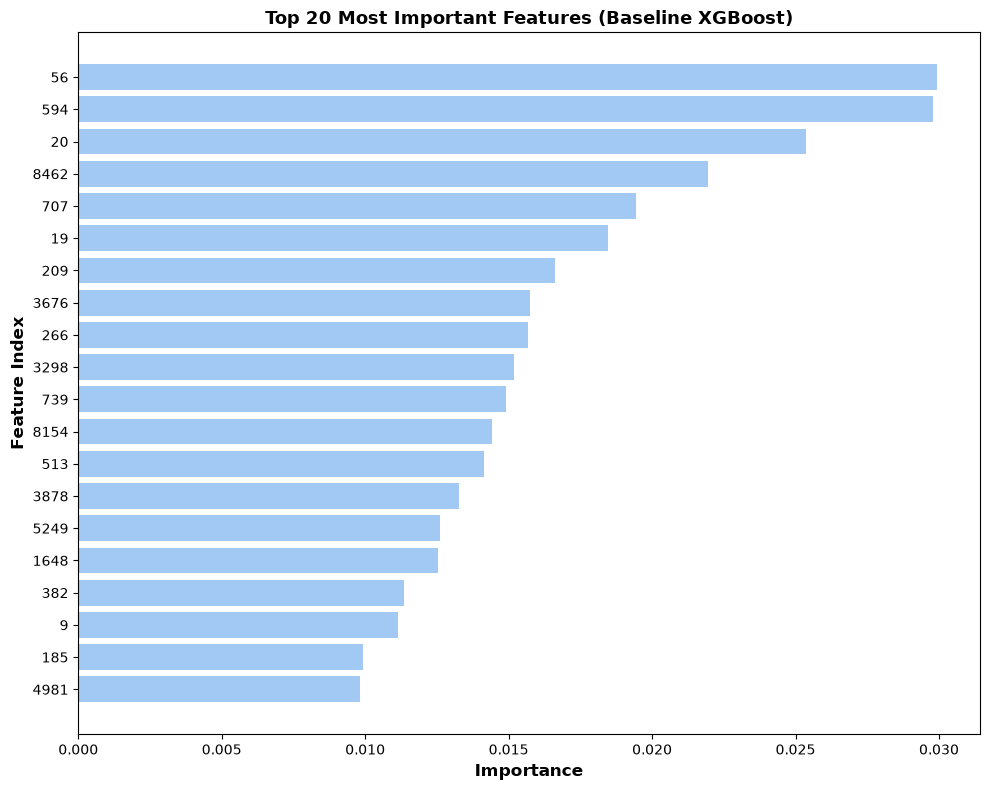


Top 10 most important features:
      feature_index  importance
56               56    0.029933
594             594    0.029801
20               20    0.025361
8462           8462    0.021935
707             707    0.019443
19               19    0.018464
209             209    0.016606
3676           3676    0.015747
266             266    0.015661
3298           3298    0.015181


In [6]:
# Get feature importances
feature_importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature_index': range(len(feature_importance)),
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance_df['importance'].head(20))
plt.yticks(range(20), feature_importance_df['feature_index'].head(20))
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature Index', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features (Baseline XGBoost)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feature_importance_df.head(10))

### **2.3 Classification Report and Confusion Matrix**

In [7]:
# Get predictions
y_test_pred = xgb_model.predict(X_test)

# Classification report
print("Classification Report (Baseline XGBoost):")
print(classification_report(y_test, y_test_pred))

Classification Report (Baseline XGBoost):
              precision    recall  f1-score   support

           0       0.81      0.69      0.75        32
           1       0.76      0.86      0.81        37

    accuracy                           0.78        69
   macro avg       0.79      0.78      0.78        69
weighted avg       0.79      0.78      0.78        69



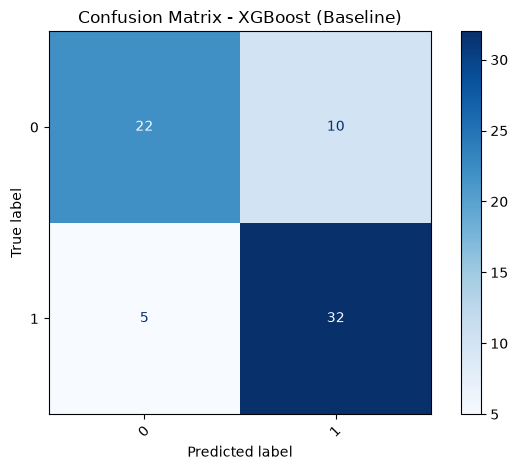

In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=xgb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - XGBoost (Baseline)")
plt.tight_layout()
plt.show()

## **3. Hyperparameter Tuning: Optimizing Regularization and Tree Parameters**

Now let's use cross-validated grid search to find optimal hyperparameters.

### **3.1 Combine Training and Validation Sets**

In [9]:
# Combine train and validation sets for grid search
X_train_total = np.vstack([X_train, X_val])
y_train_total = np.concatenate([y_train, y_val])

print(f"Combined training set shape: {X_train_total.shape}")
print(f"Combined training set labels shape: {y_train_total.shape}")

Combined training set shape: (158, 9754)
Combined training set labels shape: (158, 1)


### **3.2 Grid Search for Optimal Hyperparameters**

In [18]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'reg_alpha': [0.0, 0.1],  # L1 regularization
    'reg_lambda': [0.1, 1.0]  # L2 regularization
}

# Create grid search
grid_search = GridSearchCV(
    xgb.XGBClassifier(
        n_estimators=100,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    param_grid,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Perform grid search
print("Performing grid search")
grid_search.fit(X_train_total, y_train_total)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Performing grid search

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
Best cross-validation score: 0.8173


### **3.3 Analyze Grid Search Results**

In [19]:
# Extract results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display top results
results_display = cv_results[[
    'mean_test_score', 'std_test_score', 
    'mean_train_score', 'std_train_score',
    'param_max_depth', 'param_learning_rate', 'param_reg_alpha', 'param_reg_lambda'
]].sort_values('mean_test_score', ascending=False).head(10)

print("\nTop 10 Grid Search Results:")
print(results_display)


Top 10 Grid Search Results:
    mean_test_score  std_test_score  mean_train_score  std_train_score  \
15         0.817339        0.076638               1.0              0.0   
25         0.798992        0.100761               1.0              0.0   
13         0.798387        0.065718               1.0              0.0   
2          0.792540        0.104902               1.0              0.0   
34         0.792339        0.092542               1.0              0.0   
28         0.792339        0.096936               1.0              0.0   
27         0.792137        0.073963               1.0              0.0   
22         0.792137        0.068478               1.0              0.0   
8          0.786089        0.090160               1.0              0.0   
33         0.785887        0.073296               1.0              0.0   

    param_max_depth  param_learning_rate  param_reg_alpha  param_reg_lambda  
15                3                 0.10              0.1               1.0  


### **3.4 Visualize Learning Rate Effect**

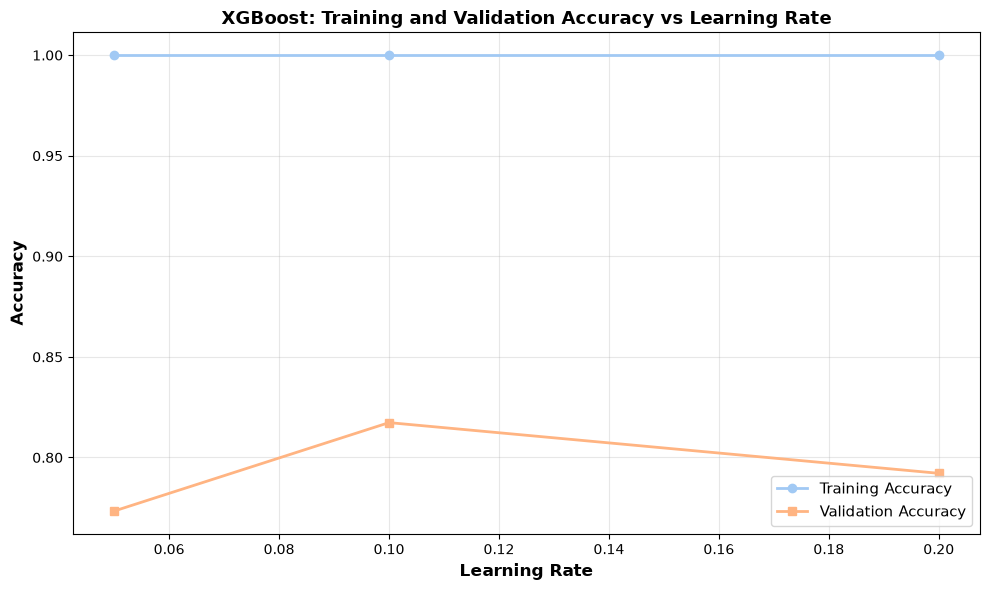

In [20]:
# Filter results for best max_depth
best_max_depth = grid_search.best_params_['max_depth']
best_reg_alpha = grid_search.best_params_['reg_alpha']
best_reg_lambda = grid_search.best_params_['reg_lambda']

filtered_results = cv_results[
    (cv_results['param_max_depth'] == best_max_depth) &
    (cv_results['param_reg_alpha'] == best_reg_alpha) &
    (cv_results['param_reg_lambda'] == best_reg_lambda)
].sort_values('param_learning_rate')

if len(filtered_results) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(
        filtered_results['param_learning_rate'],
        filtered_results['mean_train_score'],
        label='Training Accuracy',
        marker='o',
        linewidth=2
    )
    plt.plot(
        filtered_results['param_learning_rate'],
        filtered_results['mean_test_score'],
        label='Validation Accuracy',
        marker='s',
        linewidth=2
    )
    
    plt.xlabel('Learning Rate', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.title('XGBoost: Training and Validation Accuracy vs Learning Rate', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## **4. Evaluate Best Model**

In [21]:
# Evaluate best model on test set
best_xgb = grid_search.best_estimator_
accuracy_test_best = best_xgb.score(X_test, y_test)

print(f"\nBest Model Test Accuracy: {accuracy_test_best:.4f}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")


Best Model Test Accuracy: 0.7826
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
Best CV score: 0.8173


### **4.1 Feature Importance of Best Model**

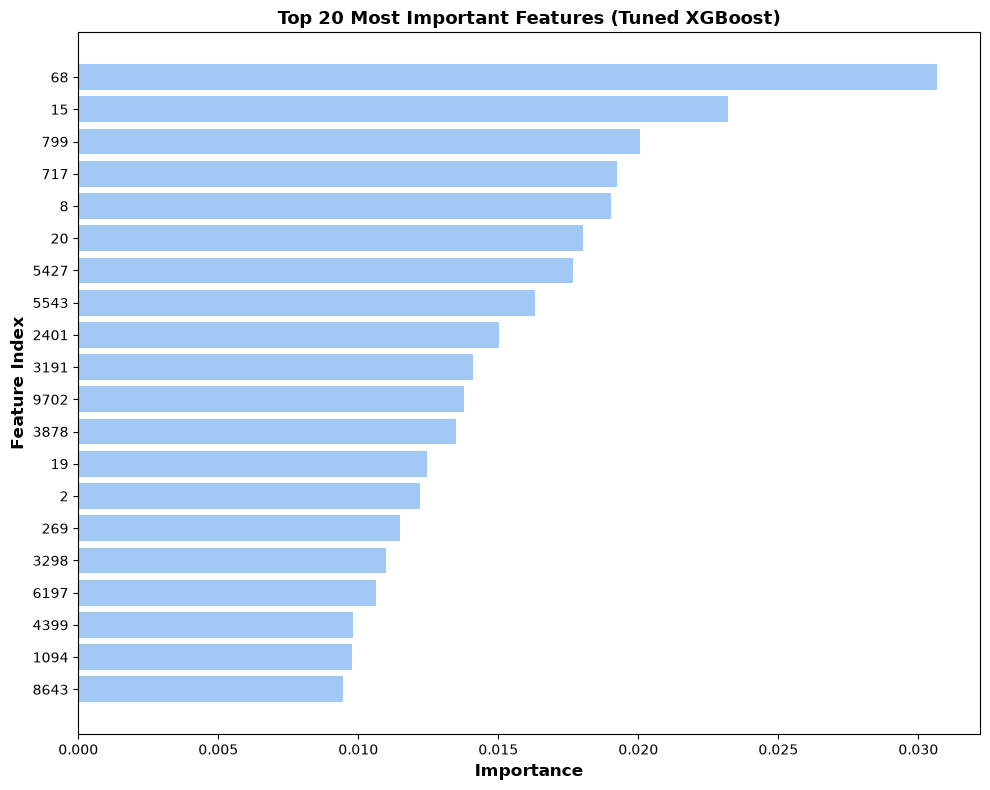


Top 10 most important features (tuned model):
      feature_index  importance
68               68    0.030668
15               15    0.023212
799             799    0.020073
717             717    0.019234
8                 8    0.019017
20               20    0.018030
5427           5427    0.017671
5543           5543    0.016295
2401           2401    0.015021
3191           3191    0.014082


In [22]:
# Get feature importances
feature_importance_best = best_xgb.feature_importances_
feature_importance_best_df = pd.DataFrame({
    'feature_index': range(len(feature_importance_best)),
    'importance': feature_importance_best
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance_best_df['importance'].head(20))
plt.yticks(range(20), feature_importance_best_df['feature_index'].head(20))
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature Index', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features (Tuned XGBoost)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features (tuned model):")
print(feature_importance_best_df.head(10))

### **4.2 Classification Report**

In [23]:
# Get predictions
y_test_pred_best = best_xgb.predict(X_test)

# Classification report
print("\nClassification Report (Best XGBoost):")
print(classification_report(y_test, y_test_pred_best))


Classification Report (Best XGBoost):
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        32
           1       0.78      0.84      0.81        37

    accuracy                           0.78        69
   macro avg       0.78      0.78      0.78        69
weighted avg       0.78      0.78      0.78        69



### **4.3 Confusion Matrix**

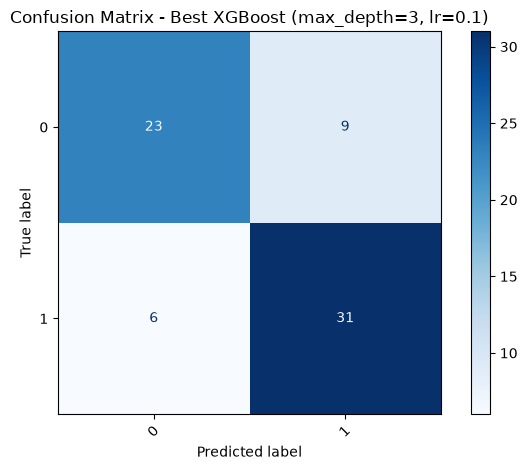

In [24]:
# Confusion matrix
cm_best = confusion_matrix(y_test, y_test_pred_best, labels=best_xgb.classes_)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=best_xgb.classes_)
disp_best.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best XGBoost (max_depth={grid_search.best_params_['max_depth']}, lr={grid_search.best_params_['learning_rate']})")
plt.tight_layout()
plt.show()

### **4.4 ROC Curve and AUC Score**

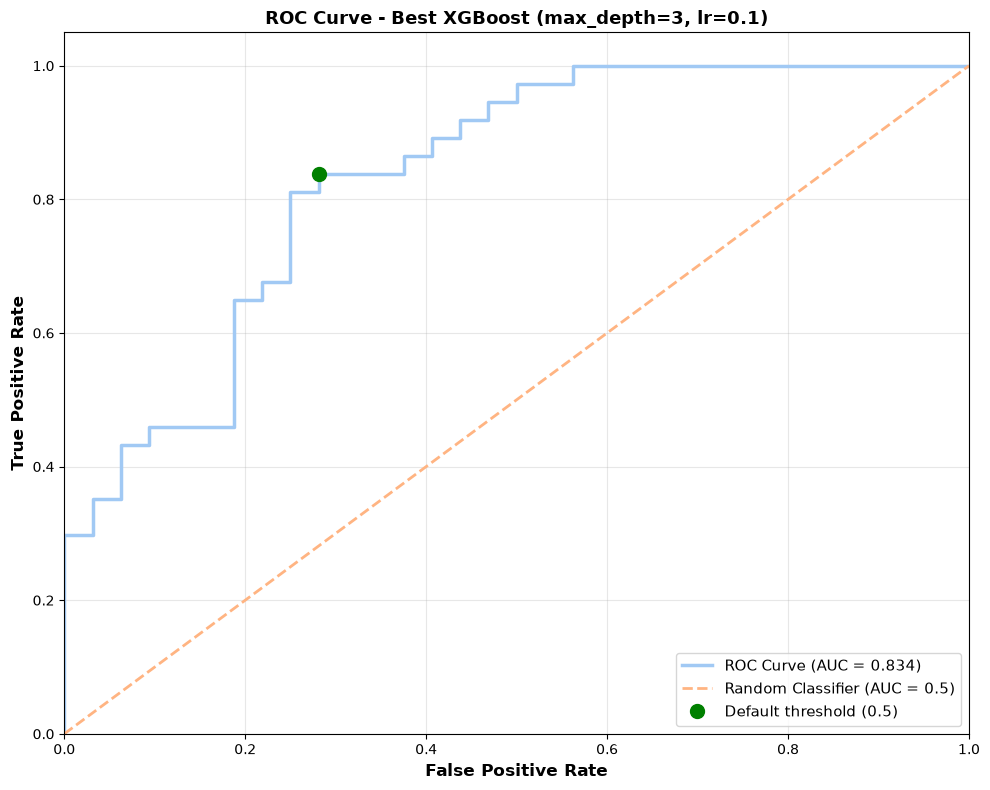


AUC Score: 0.8336
At default threshold (0.5):
  True Positive Rate (TPR): 0.838 (catch 83.8% of resistant)
  False Positive Rate (FPR): 0.281 (28.1% of susceptible misclassified)


In [26]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for the positive class
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark the default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(fpr[default_idx], tpr[default_idx], 'go', markersize=10, label='Default threshold (0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC Curve - Best XGBoost (max_depth={grid_search.best_params_["max_depth"]}, lr={grid_search.best_params_["learning_rate"]})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")
print(f"At default threshold (0.5):")
print(f"  True Positive Rate (TPR): {tpr[default_idx]:.3f} (catch {tpr[default_idx]*100:.1f}% of resistant)")
print(f"  False Positive Rate (FPR): {fpr[default_idx]:.3f} ({fpr[default_idx]*100:.1f}% of susceptible misclassified)")

## **5. Save Results**

In [27]:
import csv
import os

# Store results
results = {
    'model': 'XGBoost',
    'hyperparameters': f"max_depth={grid_search.best_params_['max_depth']}, learning_rate={grid_search.best_params_['learning_rate']}, reg_alpha={grid_search.best_params_['reg_alpha']}, reg_lambda={grid_search.best_params_['reg_lambda']}",
    'test_accuracy': float(accuracy_test_best),
    'cv_score': float(grid_search.best_score_)
}

csv_file = 'model_results.csv'

# Append results to the csv file
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writeheader()
        writer.writerow(results)
else:
    with open(csv_file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writerow(results)

print(f"\nResults saved:")
print(f"  Model: {results['model']}")
print(f"  Hyperparameters: {results['hyperparameters']}")
print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
print(f"  CV Score: {results['cv_score']:.4f}")


Results saved:
  Model: XGBoost
  Hyperparameters: max_depth=3, learning_rate=0.1, reg_alpha=0.1, reg_lambda=1.0
  Test Accuracy: 0.7826
  CV Score: 0.8173
